# Lasso Regression
- Least Absolute Shrinkage and Selection Operator Regression
- Uses the $l_1$ norm
  $$J(\theta) = MSE(\theta) + \alpha \sum_{i = 1}^{n}|\theta_i|$$
- It tends to eliminate the weights of the least important features (e.g., set them to zero)
- Automatically performs feature selection and outputs a *sparse model* (e.g., with few nonezero feature weights)

---

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

In [86]:
# Make dataset
X, y = make_regression(n_samples = 100, n_features = 1, n_informative = 1, n_targets = 1, noise = 20, random_state = 13)

# Make train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80, 1), (20, 1), (80,), (20,))

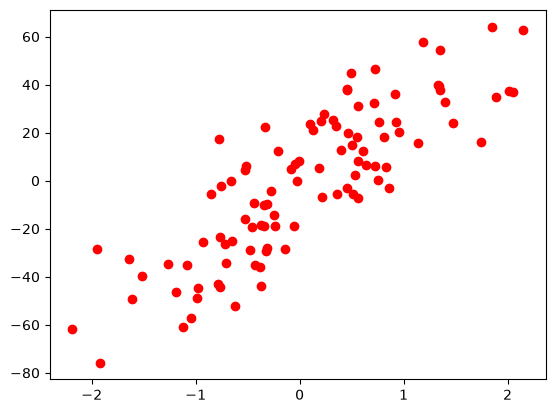

In [87]:
plt.scatter(X, y, color = 'red')
plt.show()

In [88]:
# Apply Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)


lr_reg.intercept_, lr_reg.coef_

(np.float64(-2.1509105900442553), array([28.5022326]))

In [89]:
y_pred = lr_reg.predict(X_test) 

from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.5892461404930402

When alpha = 0, r2_score = 0.5892461404930402
When alpha = 1, r2_score = 0.5966638885209556
When alpha = 5, r2_score = 0.599347288059078
When alpha = 10, r2_score = 0.5419794541912678
When alpha = 30, r2_score = -0.05578631520529864


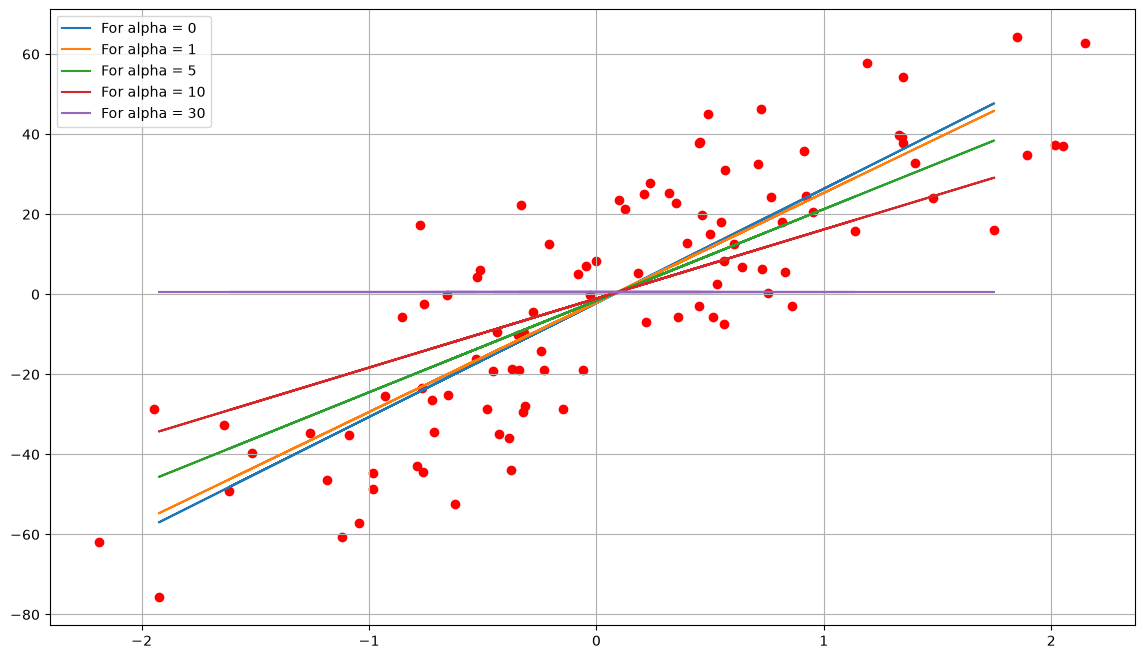

In [90]:
alpha = [0, 1, 5, 10, 30]

plt.figure(figsize = (14, 8))
plt.scatter(X,y, color = 'r')

for i in alpha:
    lasso_reg = Lasso(alpha = i)
    lasso_reg.fit(X_train, y_train)
    y_pred = lasso_reg.predict(X_test)

    plt.plot(X_test, y_pred, label = f'For alpha = {i}')

    print(f'When alpha = {i}, r2_score = {r2_score(y_test, y_pred)}')

plt.legend()
plt.grid(True)

plt.show()

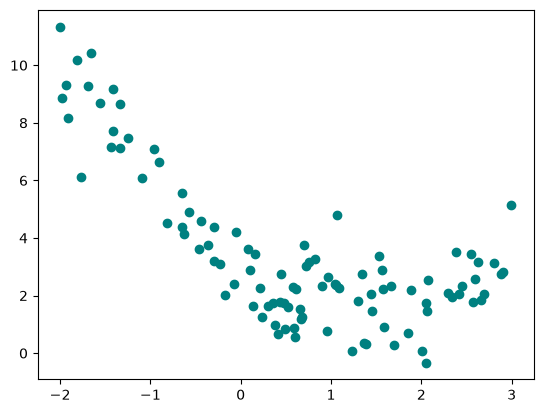

In [91]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2, color = 'teal')
plt.show()

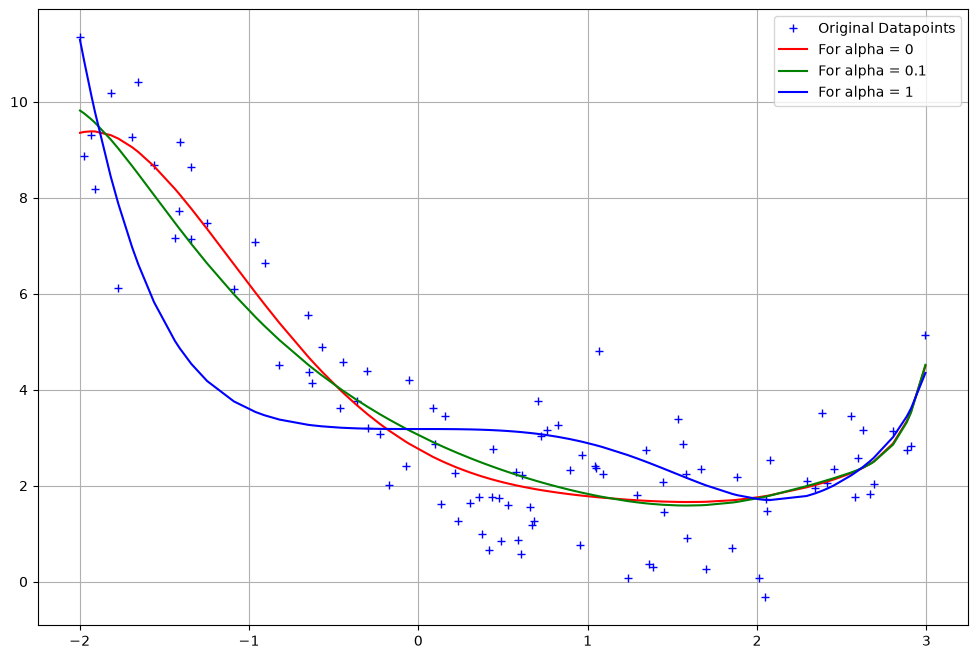

In [92]:
def get_predicts_lasso(x1,x2,alpha):
    model = Pipeline([
        ('poly_features', PolynomialFeatures(degree = 16)),
        ('lasso', Lasso(alpha = alpha))
    ])

    model.fit(x1,x2)
    return model.predict(x1)

alpha = [0, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize = (12, 8))
plt.plot(x1, x2, 'b+', label = 'Original Datapoints')

for alpha, c in zip(alpha, cs):
    preds = get_predicts_lasso(x1, x2, alpha)

    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:,0])], c, label = f'For alpha = {alpha}')

plt.legend()
plt.grid(True)

plt.show()

# Key Points

# HOW COEFFICENTS ARE AFFECTED

In [93]:
from sklearn.datasets import load_diabetes


data = load_diabetes()

df = pd.DataFrame(data.data,columns=data.feature_names)
df['TARGET'] = data.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [94]:
X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2,random_state=42)

In [95]:
coefs = []
r2_scores = []
alphas = [0,0.1,1,10]

for i in alphas:
    reg = Lasso(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_)
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test,y_pred))

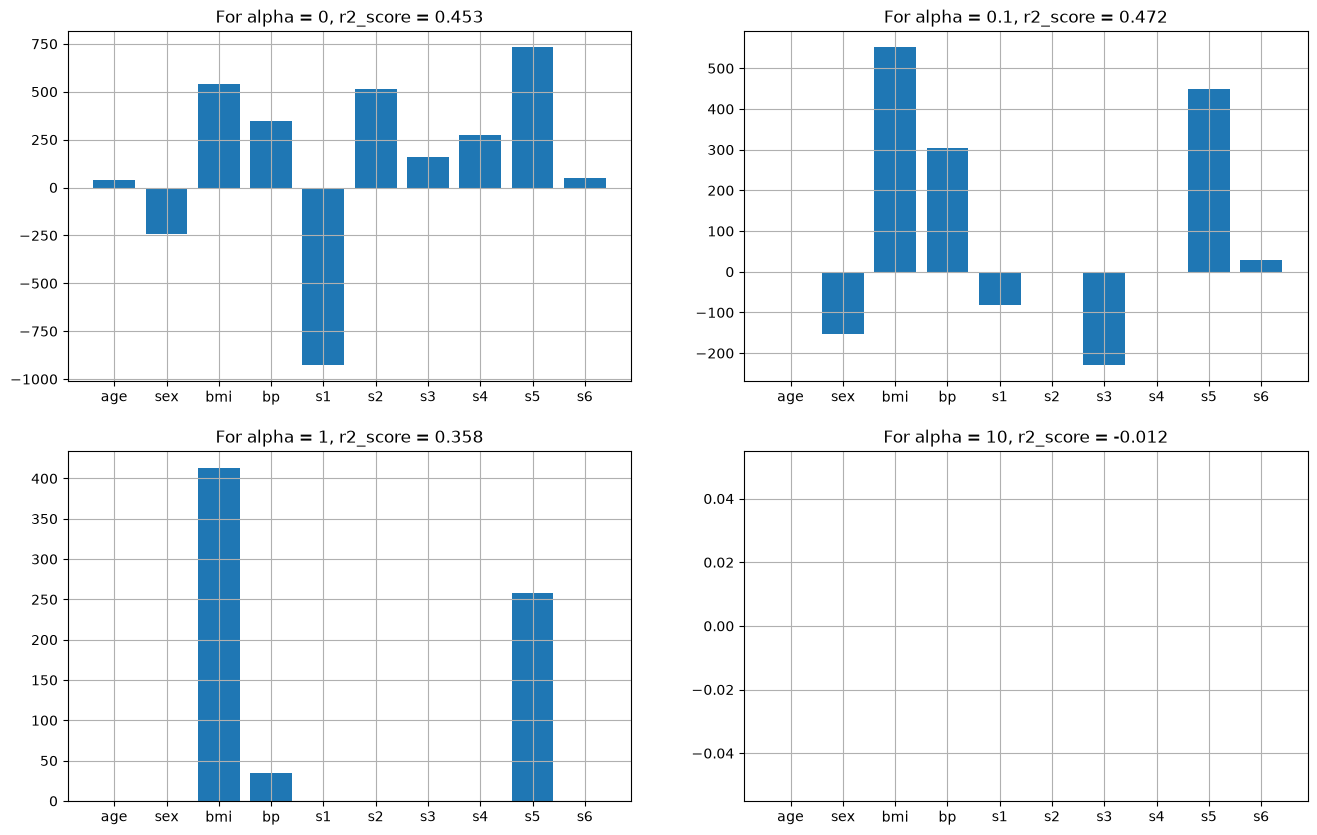

In [96]:
plt.figure(figsize = (16, 10))

plt.subplot(221)
plt.bar(data.feature_names, coefs[0])
plt.title(f'For alpha = {0}, r2_score = {r2_scores[0]:.3f}')
plt.grid(True)

plt.subplot(222)
plt.bar(data.feature_names, coefs[1])
plt.title(f'For alpha = {0.1}, r2_score = {r2_scores[1]:.3f}')
plt.grid(True)

plt.subplot(223)
plt.bar(data.feature_names, coefs[2])
plt.title(f'For alpha = {1}, r2_score = {r2_scores[2]:.3f}')
plt.grid(True)

plt.subplot(224)
plt.bar(data.feature_names, coefs[3])
plt.title(f'For alpha = {10}, r2_score = {r2_scores[3]:.3f}')
plt.grid(True)

plt.show()



# HIGHER COEFFICENTS ARE AFFECTED MORE

In [97]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]

coefs = []

for i in alphas:
    lasso_reg = Lasso(alpha = i)
    lasso_reg.fit(X_train, y_train)

    coefs.append(lasso_reg.coef_)


coef_df = pd.DataFrame(coefs, columns = data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,37.922065,-241.955823,542.511818,347.673092,-926.620276,514.293992,161.242144,274.647179,734.351559,48.690656
0.0001,37.891667,-241.878244,542.524544,347.624893,-924.832045,513.033268,160.224210,274.036385,733.762619,48.690013
0.0010,37.780431,-241.103200,543.386372,346.914418,-864.934721,467.782935,131.468467,262.504646,711.841733,48.864159
0.0100,35.347451,-231.906664,551.303242,341.313469,-483.567140,165.990532,-25.834899,216.875803,566.815003,49.702475
0.1000,0.000000,-152.664779,552.697775,303.365158,-81.365007,-0.000000,-229.255776,0.000000,447.919525,29.642617
1.0000,0.000000,-0.000000,413.431848,34.830515,0.000000,0.000000,-0.000000,0.000000,258.152894,0.000000
10.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
100.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1000.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


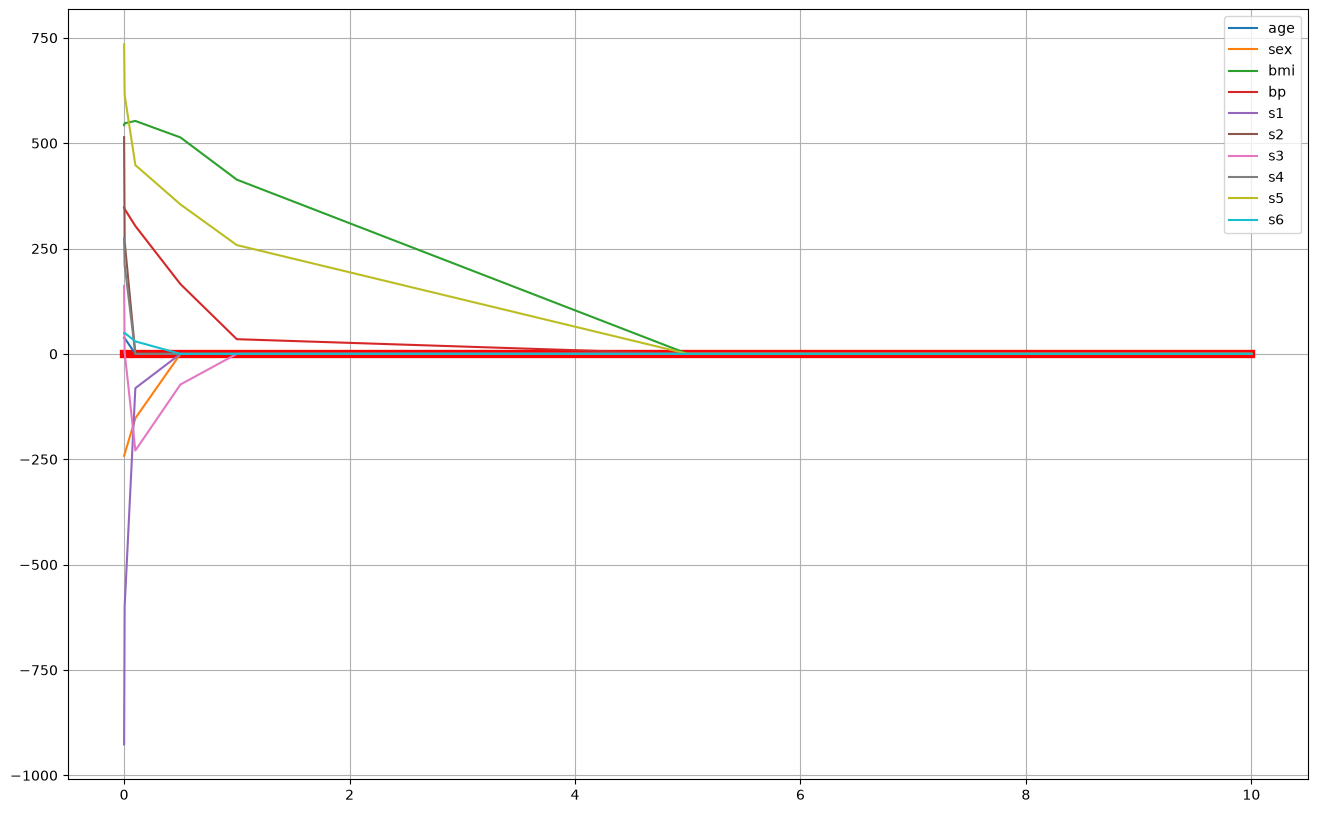

In [98]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
    reg = Lasso(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_)


input_array = np.array(coefs).T

plt.figure(figsize = (16, 10))
plt.plot(alphas, np.zeros(len(alphas)), color = 'red', linewidth = 6)

for i in range(input_array.shape[0]):
    plt.plot(alphas, input_array[i], label = data.feature_names[i])

plt.grid(True)
plt.legend()

plt.show()

# IMPACT ON BIAS & VARIANCE

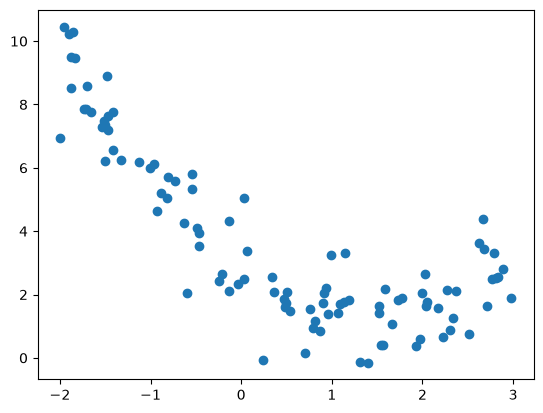

In [100]:
m = 100
X = 5 * np.random.rand(m, 1) - 2
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m, 1)

plt.scatter(X, y)
plt.show()

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 13)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80, 1), (20, 1), (80, 1), (20, 1))

In [102]:
poly = PolynomialFeatures(degree = 10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

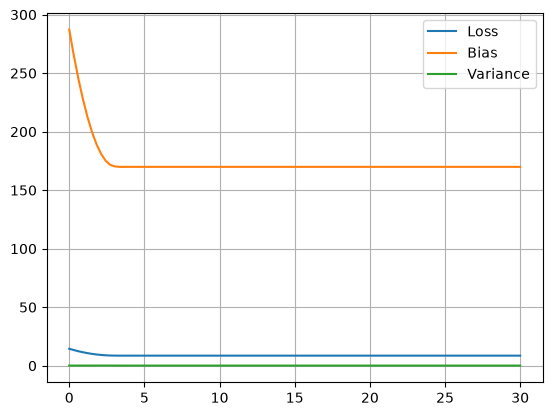

In [103]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0, 30, 100)
loss, bias, variance = [], [], []

for i in alphas:
    lasso_reg = Lasso(alpha = i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(lasso_reg, X_train, y_train, X_test, y_test, loss = 'mse', random_seed = 123)

    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)



plt.plot(alphas, loss, label = 'Loss')
plt.plot(alphas, bias, label = 'Bias')
plt.plot(alphas, variance, label = 'Variance')

plt.legend()
plt.grid(True)

plt.show()

# EFFECT OF REGULARIZATION ON LOSS FUNCTION

[27.82809103]
-2.29474455867698


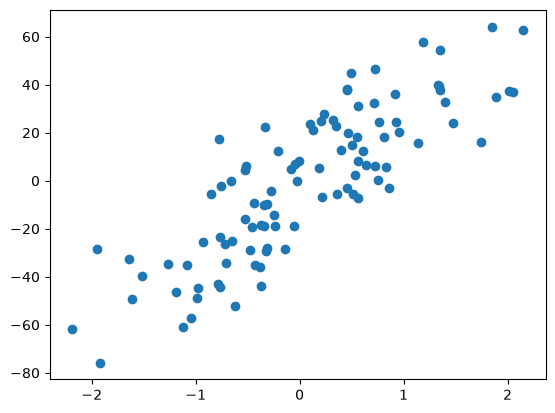

In [104]:

from sklearn.datasets import make_regression

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

In [105]:
def cal_loss(m,alpha):
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*abs(m)

def predict(m):
    return m*X - 2.29

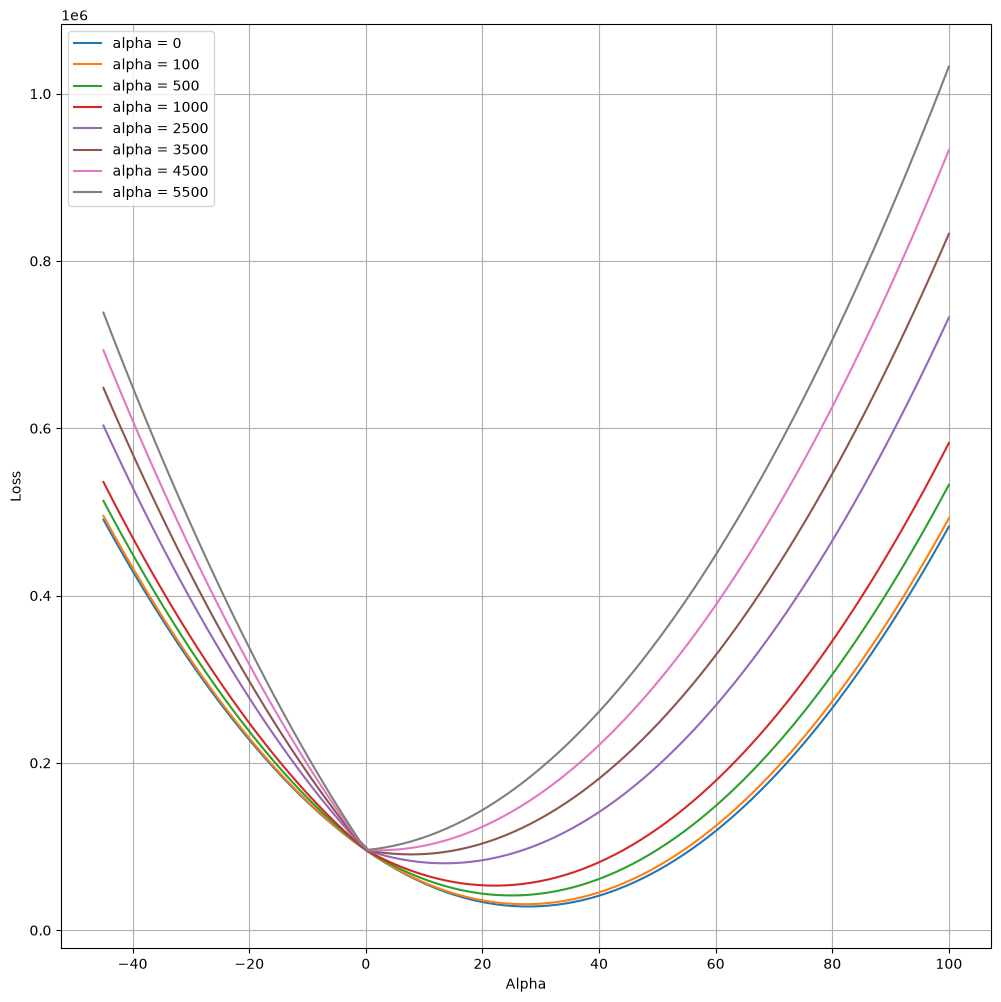

In [106]:

m = np.linspace(-45,100,100)
plt.figure(figsize=(12,12))
for j in [0,100,500,1000,2500,3500,4500,5500]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)
    plt.plot(m,loss,label='alpha = {}'.format(j))
plt.legend()
plt.xlabel('Alpha')
plt.ylabel('Loss')
plt.grid(True)

plt.show()